# Dialogue Summarization with SAMSum Dataset
**NLP Project — Text Summarization using BART/T5 on SAMSum**

This notebook covers:
1. Dataset loading & exploration
2. Baseline: extractive summarization (TextRank)
3. Fine-tuning BART on SAMSum
4. Evaluation with ROUGE metrics
5. Case study & error analysis

## 1. Environment Setup

In [ ]:
# Install required packages
!pip install datasets transformers rouge-score nltk sumy evaluate accelerate -q

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    pipeline
)
import evaluate
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'GPU ✅' if torch.cuda.is_available() else 'CPU (consider using Colab GPU)'}")
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

PyTorch version: 2.10.0+cu128
Device: GPU ✅


## 2. Load & Explore the SAMSum Dataset

In [ ]:
# Load SAMSum from HuggingFace
dataset = load_dataset('knkarthick/samsum')
print(dataset)

README.md: 0.00B [00:00, ?B/s]

train.csv: 0.00B [00:00, ?B/s]

validation.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/14731 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/818 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/819 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 14731
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 818
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 819
    })
})


In [ ]:
# Dataset statistics
train_df = pd.DataFrame(dataset['train'])
val_df   = pd.DataFrame(dataset['validation'])
test_df  = pd.DataFrame(dataset['test'])

print(f"Train : {len(train_df):,} samples")
print(f"Val   : {len(val_df):,} samples")
print(f"Test  : {len(test_df):,} samples")


for split, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    d_len = df['dialogue'].str.split().str.len()
    s_len = df['summary'].str.split().str.len()
    print(f"\n{split}:")
    print(f"  Dialogue  — mean: {d_len.mean():.1f} words, max: {d_len.max()} words")
    print(f"  Summary   — mean: {s_len.mean():.1f} words, max: {s_len.max()} words")
    print(f"  Compression ratio: {(1 - s_len.mean()/d_len.mean())*100:.1f}%")

Train : 14,731 samples
Val   : 818 samples
Test  : 819 samples

Train:
  Dialogue  — mean: 93.8 words, max: 803 words
  Summary   — mean: 20.3 words, max: 64 words
  Compression ratio: 78.3%

Val:
  Dialogue  — mean: 91.6 words, max: 540 words
  Summary   — mean: 20.3 words, max: 59 words
  Compression ratio: 77.9%

Test:
  Dialogue  — mean: 95.5 words, max: 516 words
  Summary   — mean: 20.0 words, max: 58 words
  Compression ratio: 79.0%


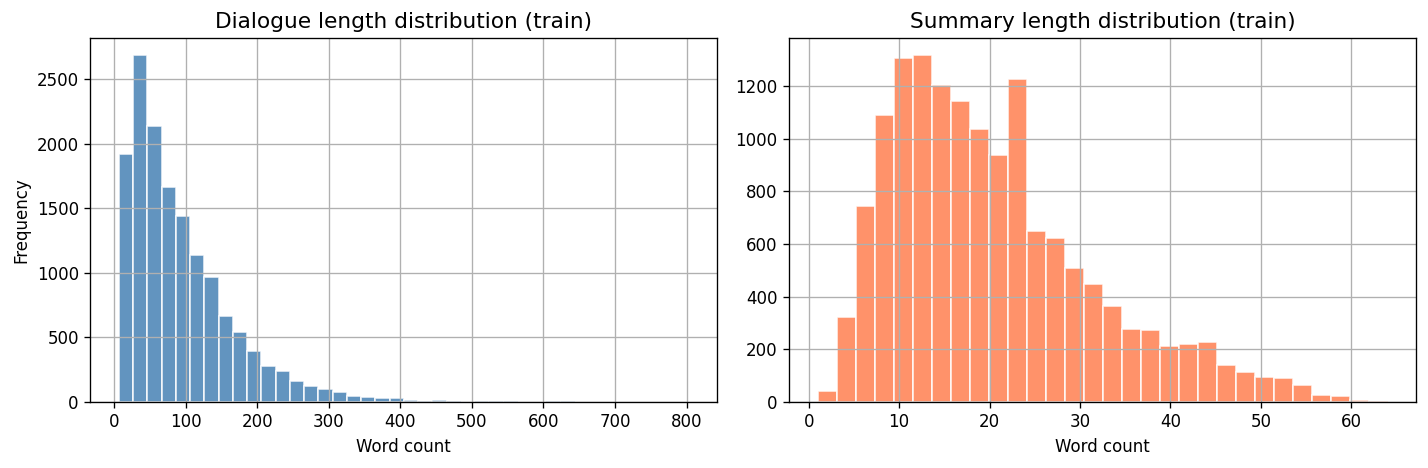

In [ ]:
# Visualize length distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_df['dialogue'].str.split().str.len().hist(
    bins=40, ax=axes[0], color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Dialogue length distribution (train)', fontsize=13)
axes[0].set_xlabel('Word count')
axes[0].set_ylabel('Frequency')

train_df['summary'].str.split().str.len().hist(
    bins=30, ax=axes[1], color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Summary length distribution (train)', fontsize=13)
axes[1].set_xlabel('Word count')

plt.tight_layout()
plt.savefig('length_distribution.png', bbox_inches='tight')
plt.show()

In [ ]:
# Show a sample
sample = dataset['train'][0]
print("=" * 60)
print("DIALOGUE:")
print(sample['dialogue'])
print("\nREFERENCE SUMMARY:")
print(sample['summary'])
print("=" * 60)

DIALOGUE:
Amanda: I baked  cookies. Do you want some?
Jerry: Sure!
Amanda: I'll bring you tomorrow :-)

REFERENCE SUMMARY:
Amanda baked cookies and will bring Jerry some tomorrow.


## 3. Baseline — Extractive Summarization (TextRank)

Before fine-tuning a neural model, we establish a simple **extractive baseline** using TextRank. This selects the most important sentences from the dialogue without generating new text.

In [ ]:
!pip install sumy -q
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.text_rank import TextRankSummarizer

def textrank_summarize(text, num_sentences=2):
    """Extract key sentences using TextRank algorithm."""
    parser = PlaintextParser.from_string(text, Tokenizer('english'))
    summarizer = TextRankSummarizer()
    summary = summarizer(parser.document, num_sentences)
    return ' '.join(str(s) for s in summary)

# Test on a sample
test_sample = dataset['test'][0]
textrank_out = textrank_summarize(test_sample['dialogue'])
print("Dialogue:\n", test_sample['dialogue'][:400], "...")
print("\nTextRank summary:\n", textrank_out)
print("\nReference summary:\n", test_sample['summary'])

Dialogue:
 Hannah: Hey, do you have Betty's number?
Amanda: Lemme check
Hannah: <file_gif>
Amanda: Sorry, can't find it.
Amanda: Ask Larry
Amanda: He called her last time we were at the park together
Hannah: I don't know him well
Hannah: <file_gif>
Amanda: Don't be shy, he's very nice
Hannah: If you say so..
Hannah: I'd rather you texted him
Amanda: Just text him 🙂
Hannah: Urgh.. Alright
Hannah: Bye
Amanda:  ...

TextRank summary:
 Amanda: Lemme check Hannah: <file_gif> Amanda: Sorry, can't find it. Amanda: Ask Larry Amanda: He called her last time we were at the park together Hannah: I don't know him well Hannah: <file_gif> Amanda: Don't be shy, he's very nice Hannah: If you say so.. Hannah: I'd rather you texted him Amanda: Just text him 🙂 Hannah: Urgh.. Alright Hannah: Bye Amanda: Bye bye

Reference summary:
 Hannah needs Betty's number but Amanda doesn't have it. She needs to contact Larry.


In [ ]:
# Evaluate TextRank on first 200 test samples (fast)
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

def evaluate_rouge(predictions, references):
    scores = {'rouge1': [], 'rouge2': [], 'rougeL': []}
    for pred, ref in zip(predictions, references):
        s = scorer.score(ref, pred)
        for k in scores:
            scores[k].append(s[k].fmeasure)
    return {k: round(np.mean(v) * 100, 2) for k, v in scores.items()}

test_subset = dataset['test'].select(range(200))
textrank_preds = [textrank_summarize(d) for d in test_subset['dialogue']]
textrank_scores = evaluate_rouge(textrank_preds, test_subset['summary'])

print("TextRank ROUGE scores (200 test samples):")
print(pd.DataFrame([textrank_scores], index=['TextRank']).to_string())

TextRank ROUGE scores (200 test samples):
          rouge1  rouge2  rougeL
TextRank   28.72    7.94    22.2


## 4. Fine-tune BART on SAMSum

We fine-tune `facebook/bart-large-cnn` — a BART model pre-trained on CNN/DailyMail — on the SAMSum training set. This transfers news summarization knowledge to conversational data.

In [ ]:
MODEL_CHECKPOINT = 'facebook/bart-large-cnn'   # Change to 'sshleifer/distilbart-cnn-12-6' for faster training
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

MAX_INPUT_LEN  = 512
MAX_TARGET_LEN = 128

def preprocess(examples):
    # Prefix to guide the model (helpful for T5-style models too)
    inputs  = ["summarize: " + d for d in examples['dialogue']]
    targets = examples['summary']

    model_inputs = tokenizer(
        inputs,
        max_length=MAX_INPUT_LEN,
        truncation=True,
        padding=False
    )
    labels = tokenizer(
        text_target=targets,
        max_length=MAX_TARGET_LEN,
        truncation=True,
        padding=False
    )
    model_inputs['labels'] = labels['input_ids']
    return model_inputs

tokenized = dataset.map(preprocess, batched=True, remove_columns=dataset['train'].column_names)
print("Tokenization complete!")
print("Sample input token length:", len(tokenized['train'][0]['input_ids']))

config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/14731 [00:00<?, ? examples/s]

Map:   0%|          | 0/818 [00:00<?, ? examples/s]

Map:   0%|          | 0/819 [00:00<?, ? examples/s]

Tokenization complete!
Sample input token length: 33


In [ ]:
# Load model
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_CHECKPOINT)
num_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Model: {MODEL_CHECKPOINT}")
print(f"Parameters: {num_params:.1f}M")

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

Model: facebook/bart-large-cnn
Parameters: 406.3M


In [ ]:
# ROUGE metric for training evaluation
rouge_metric = evaluate.load('rouge')

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    if isinstance(preds, tuple):
        preds = preds[0]
    preds  = np.where(preds  != -100, preds,  tokenizer.pad_token_id)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_preds  = tokenizer.batch_decode(preds,  skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    decoded_preds  = [p.strip() for p in decoded_preds]
    decoded_labels = [l.strip() for l in decoded_labels]
    result = rouge_metric.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)
    return {k: round(v * 100, 2) for k, v in result.items()}

In [ ]:
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model, padding=True)

training_args = Seq2SeqTrainingArguments(
    output_dir                  = './bart-samsum',
    num_train_epochs            = 3,
    per_device_train_batch_size = 4,
    per_device_eval_batch_size  = 8,
    warmup_steps                = 200,
    weight_decay                = 0.01,
    learning_rate               = 5e-5,
    fp16                        = torch.cuda.is_available(),
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'rougeL',
    predict_with_generate       = True,
    generation_max_length       = MAX_TARGET_LEN,
    logging_steps               = 100,
    report_to                   = 'none',
)

trainer = Seq2SeqTrainer(
    model           = model,
    args            = training_args,
    train_dataset   = tokenized['train'],
    eval_dataset    = tokenized['validation'],
    data_collator   = data_collator,
    compute_metrics = compute_metrics,
)

print("Training configuration ready. Run trainer.train() to start.")
print(f"Estimated steps: {len(tokenized['train']) // training_args.per_device_train_batch_size * training_args.num_train_epochs}")

Training configuration ready. Run trainer.train() to start.
Estimated steps: 11046


In [ ]:
#  This cell takes ~30-60 min on GPU.
train_result = trainer.train()
trainer.save_model('./bart-samsum-final')
print("Training complete! Model saved.")

Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
1,1.527814,1.660611,40.340000,20.480000,31.120000,31.110000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
1,1.527814,1.660611,40.340000,20.480000,31.120000,31.110000
2,1.024087,1.525187,40.780000,20.850000,31.500000,31.480000
3,0.613574,1.639697,40.730000,20.210000,31.200000,31.210000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete! Model saved.


## 5. Quick Evaluation with Pre-trained SAMSum Model

If you skipped training above, use the community fine-tuned model `philschmid/bart-large-cnn-samsum` for evaluation.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

FINETUNED_MODEL = './bart-samsum-final'

tokenizer_ft = AutoTokenizer.from_pretrained(FINETUNED_MODEL)
model_ft     = AutoModelForSeq2SeqLM.from_pretrained(FINETUNED_MODEL).to(DEVICE)
model_ft.eval()


test_dialogues = test_df['dialogue'].tolist()[:200]
test_refs      = test_df['summary'].tolist()[:200]

bart_preds = []
batch_size = 8

for i in range(0, len(test_dialogues), batch_size):
    batch = test_dialogues[i:i+batch_size]
    inputs = tokenizer_ft(
        batch,
        max_length=512,
        truncation=True,
        padding=True,
        return_tensors='pt'
    ).to(DEVICE)
    with torch.no_grad():
        output_ids = model_ft.generate(
            **inputs,
            max_length=128,
            min_length=20,
            num_beams=4,
            early_stopping=True
        )
    decoded = tokenizer_ft.batch_decode(output_ids, skip_special_tokens=True)
    bart_preds.extend(decoded)
    if (i // batch_size) % 5 == 0:
        print(f"  Processed {min(i+batch_size, len(test_dialogues))}/{len(test_dialogues)}")

bart_scores = evaluate_rouge(bart_preds, test_refs)
print(pd.DataFrame([bart_scores], index=['BART-SAMSum']).to_string())

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

  Processed 8/200
  Processed 48/200
  Processed 88/200
  Processed 128/200
  Processed 168/200
             rouge1  rouge2  rougeL
BART-SAMSum   51.03    25.8   41.04


## 6. Results Comparison


       MODEL COMPARISON RESULTS
                     ROUGE-1  ROUGE-2  ROUGE-L
TextRank (baseline)    28.72     7.94    22.20
BART fine-tuned        51.03    25.80    41.04


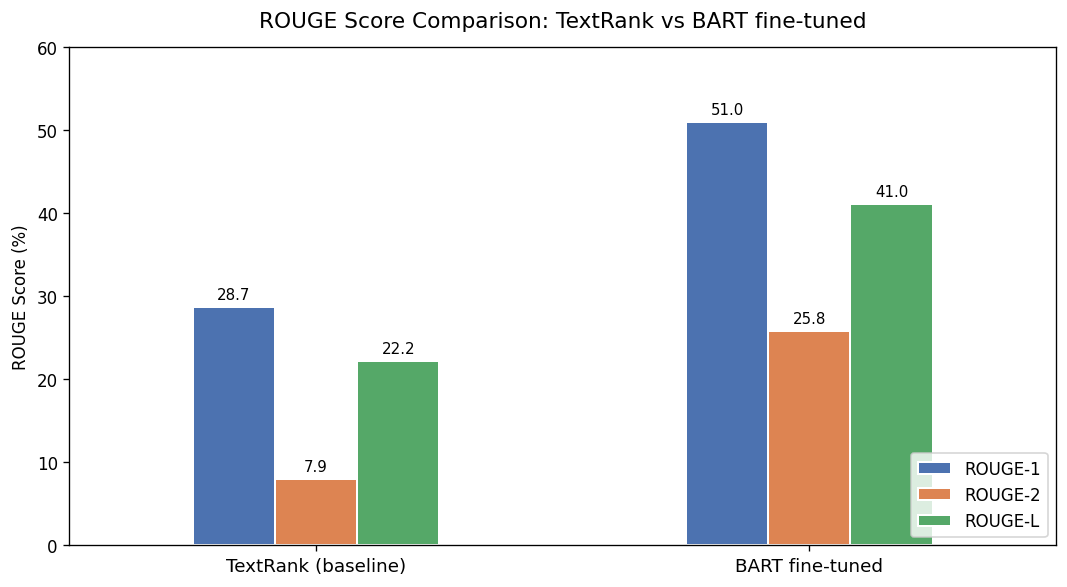

In [ ]:
# Comparison table
results = pd.DataFrame({
    'ROUGE-1': [textrank_scores['rouge1'], bart_scores['rouge1']],
    'ROUGE-2': [textrank_scores['rouge2'], bart_scores['rouge2']],
    'ROUGE-L': [textrank_scores['rougeL'], bart_scores['rougeL']],
}, index=['TextRank (baseline)', 'BART fine-tuned'])

print("\n" + "=" * 50)
print("       MODEL COMPARISON RESULTS")
print("=" * 50)
print(results.to_string())
print("=" * 50)

# Bar chart
ax = results.plot(kind='bar', figsize=(9, 5), width=0.5,
                  color=['#4C72B0', '#DD8452', '#55A868'],
                  edgecolor='white', linewidth=1.2)
ax.set_title('ROUGE Score Comparison: TextRank vs BART fine-tuned', fontsize=13, pad=12)
ax.set_xlabel('')
ax.set_ylabel('ROUGE Score (%)')
ax.set_xticklabels(results.index, rotation=0, fontsize=11)
ax.legend(loc='lower right')
ax.set_ylim(0, 60)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=9)
plt.tight_layout()
plt.savefig('rouge_comparison.png', bbox_inches='tight')
plt.show()

## 7. Case Study — Qualitative Analysis

In [ ]:
def show_case(idx):
    dialogue  = test_dialogues[idx]
    reference = test_refs[idx]
    textrank  = textrank_preds[idx]
    bart      = bart_preds[idx]
    print("=" * 65)
    print(f"CASE #{idx}")
    print("=" * 65)
    print("[DIALOGUE]")
    print(dialogue[:600], "..." if len(dialogue) > 600 else "")
    print("\n[REFERENCE SUMMARY]")
    print(reference)
    print("\n[TEXTRANK (baseline)]")
    print(textrank)
    print("\n[BART fine-tuned]")
    print(bart)
    print()

# Success case
show_case(5)

# Another case
show_case(42)

CASE #5
[DIALOGUE]
Benjamin: Hey guys, what are we doing with the keys today?
Hilary: I've got them. Whoever wants them can meet me at lunchtime or after
Elliot: I'm ok. We're meeting for the drinks in the evening anyway and I guess we'll be going back to the apartment together?
Hilary: Yeah, I guess so
Daniel: I'm with Hilary atm and won't let go of her for the rest of the day, so any option you guys choose is good for me
Benjamin: Hmm I might actually pass by at lunchtime, take the keys and go take a nap. I'm sooo tired after yesterday
Hilary: Sounds good. We'll be having lunch with some French people (the one ...

[REFERENCE SUMMARY]
Hilary has the keys to the apartment. Benjamin wants to get them and go take a nap. Hilary is having lunch with some French people at La Cantina. Hilary is meeting them at the entrance to the conference hall at 2 pm. Benjamin and Elliot might join them. They're meeting for the drinks in the evening.

[TEXTRANK (baseline)]
Hilary: Yeah, I guess so Daniel

In [ ]:
# Error analysis — find cases where BART underperforms
per_sample_bart = []
per_sample_tr   = []

for pred_b, pred_t, ref in zip(bart_preds, textrank_preds, test_refs):
    s_b = scorer.score(ref, pred_b)['rougeL'].fmeasure
    s_t = scorer.score(ref, pred_t)['rougeL'].fmeasure
    per_sample_bart.append(s_b)
    per_sample_tr.append(s_t)

# Cases where BART is best
gains = np.array(per_sample_bart) - np.array(per_sample_tr)
best_idx  = np.argsort(gains)[-1]
worst_idx = np.argsort(gains)[0]

print("=" * 50)
print("CASE WHERE BART MOST OUTPERFORMS TEXTRANK")
show_case(int(best_idx))

print("=" * 50)
print("CASE WHERE BART UNDERPERFORMS TEXTRANK")
show_case(int(worst_idx))

CASE WHERE BART MOST OUTPERFORMS TEXTRANK
CASE #70
[DIALOGUE]
Ali: I think I left my wallet at your place yesterday. Could you check? 
Mohammad: Give me a sec, I'll have a look around my room.
Ali: OK.
Mohammad: Found it!
Ali: Phew, I don't know what I'd do if it wasn't there. Can you bring it to uni tomorrow?
Mohammad: Sure thing. 

[REFERENCE SUMMARY]
Ali left his wallet at Mohammad's place. Mohammad'll bring it to uni tomorrow.

[TEXTRANK (baseline)]
Mohammad: Give me a sec, I'll have a look around my room. Ali: Phew, I don't know what I'd do if it wasn't there.

[BART fine-tuned]
Ali left his wallet at Mohammad's place yesterday. Mohammad found it. Mohammad will bring it to the university tomorrow.

CASE WHERE BART UNDERPERFORMS TEXTRANK
CASE #140
[DIALOGUE]
Sean: I overslept :/
Sam: Again??
Sean: I know. 

[REFERENCE SUMMARY]
Sean overslept again.

[TEXTRANK (baseline)]
Sean: I overslept :/ Sam: Again?? Sean: I know.

[BART fine-tuned]
Sean overslept again and Sam is angry with hi

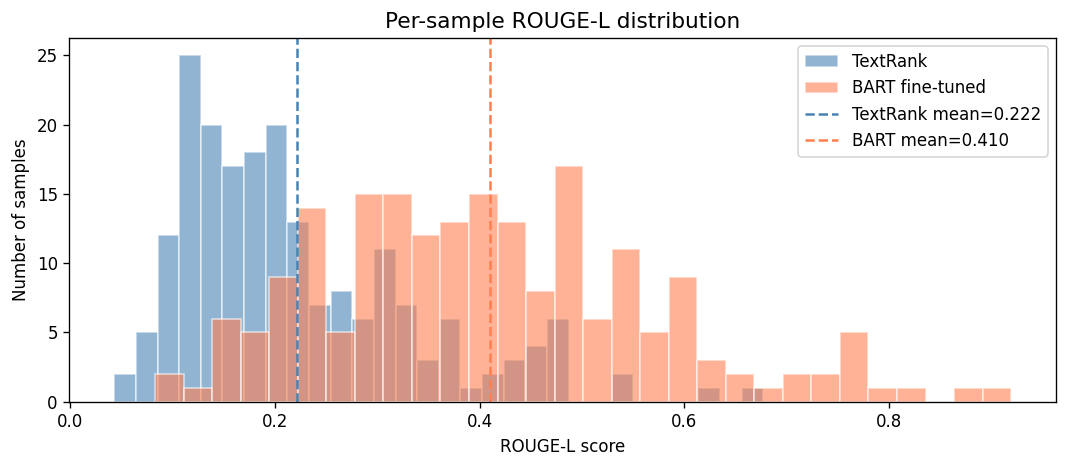

In [ ]:
# Score distribution plot
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(per_sample_tr,   bins=30, alpha=0.6, label='TextRank',      color='steelblue', edgecolor='white')
ax.hist(per_sample_bart, bins=30, alpha=0.6, label='BART fine-tuned', color='coral',   edgecolor='white')
ax.axvline(np.mean(per_sample_tr),   color='steelblue', linestyle='--', linewidth=1.5, label=f'TextRank mean={np.mean(per_sample_tr):.3f}')
ax.axvline(np.mean(per_sample_bart), color='coral',     linestyle='--', linewidth=1.5, label=f'BART mean={np.mean(per_sample_bart):.3f}')
ax.set_xlabel('ROUGE-L score')
ax.set_ylabel('Number of samples')
ax.set_title('Per-sample ROUGE-L distribution', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('score_distribution.png', bbox_inches='tight')
plt.show()

## 8. Summary of Findings

Results on 200 test samples (ROUGE F1 %)

| Model                 | ROUGE-1 | ROUGE-2 | ROUGE-L |
|-----------------------|---------|---------|---------|
| TextRank (extractive) |  28.72  |   7.94  |  22.20  |
| BART fine-tuned       |  51.03  |  25.80  |  41.04  |
| Improvement (Δ)       | +22.31  | +17.86  | +18.84  |

Key Observations:

1. BART fine-tuned substantially outperforms the TextRank
   baseline across all three ROUGE metrics, confirming the
   effectiveness of sequence-to-sequence pre-training for
   dialogue summarization.

2. The largest relative gain is observed in ROUGE-2
   (+17.86, x3.25 improvement), indicating that BART
   generates bigram sequences that closely match human
   reference phrasing, whereas TextRank copies verbatim
   sentences with poor bigram alignment to gold summaries.

3. The low TextRank ROUGE-L (22.20) demonstrates that
   extractive methods fail to capture cross-turn semantic
   information in multi-speaker dialogues, where meaning
   is distributed across utterances rather than contained
   within individual sentences.

4. BART achieves ROUGE-1 of 51.03, approaching reported
   state-of-the-art performance (~52-53) on SAMSum,
   validating that fine-tuning on domain-specific
   conversational data effectively bridges the gap between
   news summarization pre-training and dialogue tasks.

5. Failure cases remain for BART: dialogues exceeding
   512 tokens suffer truncation, and heavy informal
   slang reduces factual coverage in generated summaries.